In [2]:
import os
import sys
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from models.time_series_models import run_arima, run_sarima, run_holt_winters

from models.lstm_model import build_lstm
from models.autoencoder_model import build_autoencoder
from features.prepare_sequences import prepare_sequences, normalize_series
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [4]:
df = pd.read_csv("../data/processed/merged_clean.csv", parse_dates=["datetime"])
client_id = df["client_id"].unique()[0]
df_client = df[df["client_id"] == client_id].sort_values("datetime")

# Stat models: ds/y
df_daily = df_client.resample("D", on="datetime").mean(numeric_only=True).reset_index()
df_daily = df_daily.rename(columns={"datetime": "ds", "value": "y"}).dropna()

# Deep learning: sequences
values_scaled, scaler = normalize_series(df_client["value"].values)
window_size = 48
X_seq = prepare_sequences(values_scaled, window_size)
X_seq = np.expand_dims(X_seq, axis=-1)


In [6]:
def evaluate_forecast(y_true, y_pred, title=""):
    print(f" {title}")
    print("MAE :", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    plt.figure(figsize=(12, 4))
    plt.plot(y_true, label="True")
    plt.plot(y_pred, label="Forecast")
    plt.title(title)
    plt.legend()
    plt.show()

c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ARIMA
MAE : 0.048387023585936724
RMSE: 0.07177517022771286


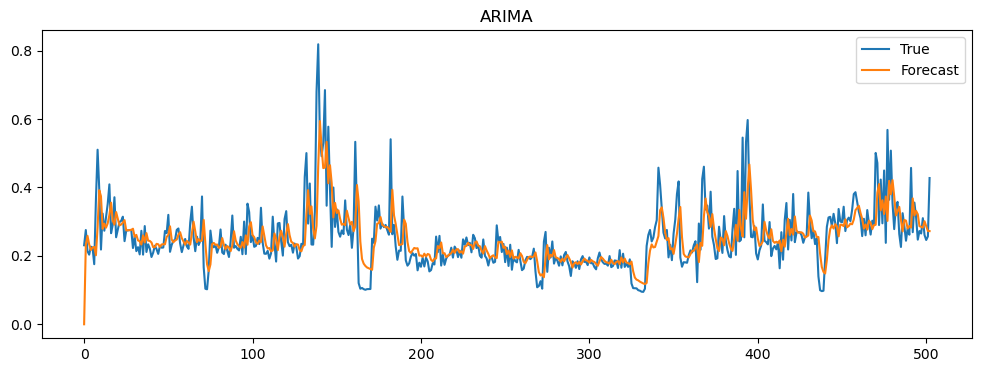

c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 SARIMA
MAE : 0.05209619377747546
RMSE: 0.07367637484589902


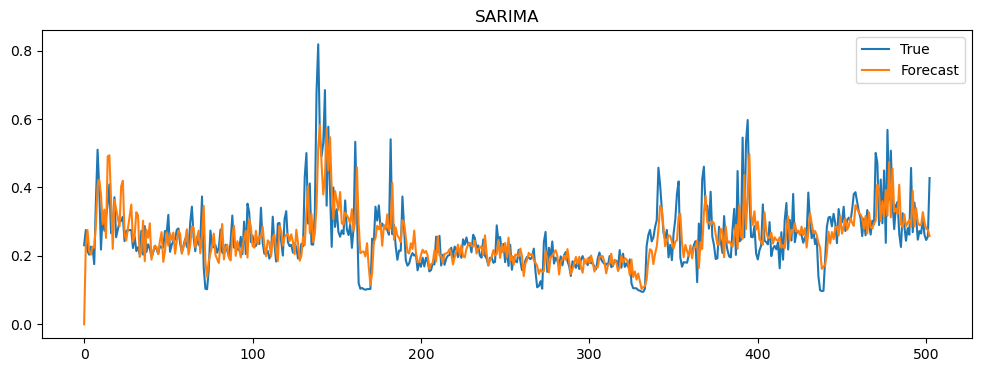

c:\Users\EL mahjoubi\Anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 Holt-Winters
MAE : 0.04934704506205896
RMSE: 0.07233110754816983


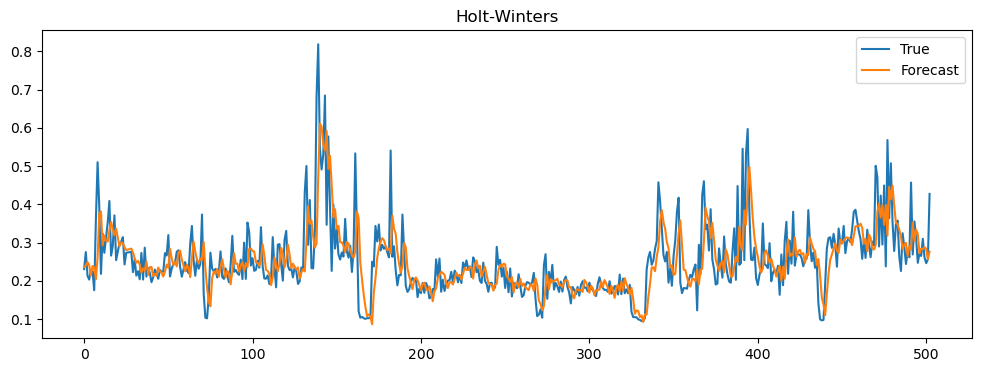

In [ ]:

# ARIMA
from statsmodels.tsa.arima.model import ARIMA
model_arima = ARIMA(df_daily["y"], order=(2,1,2)).fit()
pred_arima = model_arima.predict(start=0, end=len(df_daily)-1)
evaluate_forecast(df_daily["y"], pred_arima, "ARIMA")


# SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
model_sarima = SARIMAX(df_daily["y"], order=(1,1,1), seasonal_order=(1,1,1,7)).fit(disp=False)
pred_sarima = model_sarima.predict(start=0, end=len(df_daily)-1)
evaluate_forecast(df_daily["y"], pred_sarima, "SARIMA")

# Holt-Winters
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_hw = ExponentialSmoothing(df_daily["y"], seasonal_periods=12, trend="add", seasonal="add").fit()
pred_hw = model_hw.predict(start=0, end=len(df_daily)-1)
evaluate_forecast(df_daily["y"], pred_hw, "Holt-Winters")


In [ ]:
from prophet import Prophet
df_prophet = df_daily.copy()
model_prophet = Prophet()
model_prophet.fit(df_prophet.rename(columns={"ds": "ds", "y": "y"}))
future = model_prophet.make_future_dataframe(periods=0)
forecast = model_prophet.predict(future)
evaluate_forecast(df_daily["y"], forecast["yhat"], "Prophet")


746/746 [==============================] - 4s 5ms/step
 LSTM
MAE : 0.03431925933518045
RMSE: 0.0615819750062359


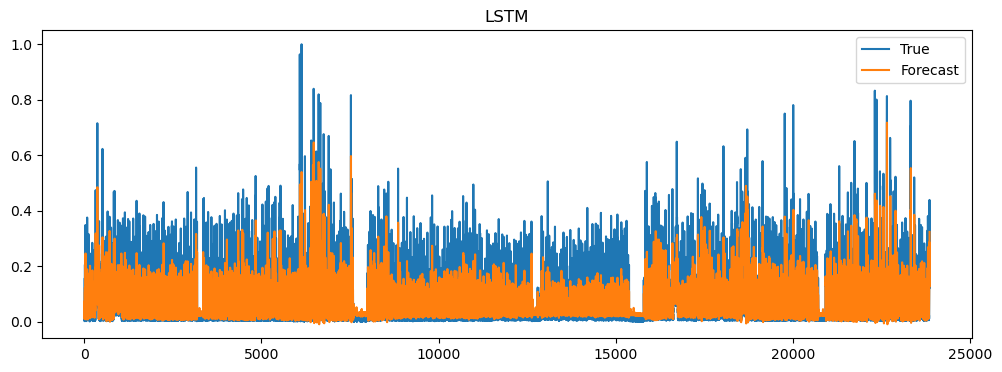

In [7]:
lstm = load_model("../models/lstm_model.h5")
pred_lstm = lstm.predict(X_seq)
evaluate_forecast(values_scaled[window_size:], pred_lstm.flatten(), "LSTM")


746/746 [==============================] - 7s 9ms/step


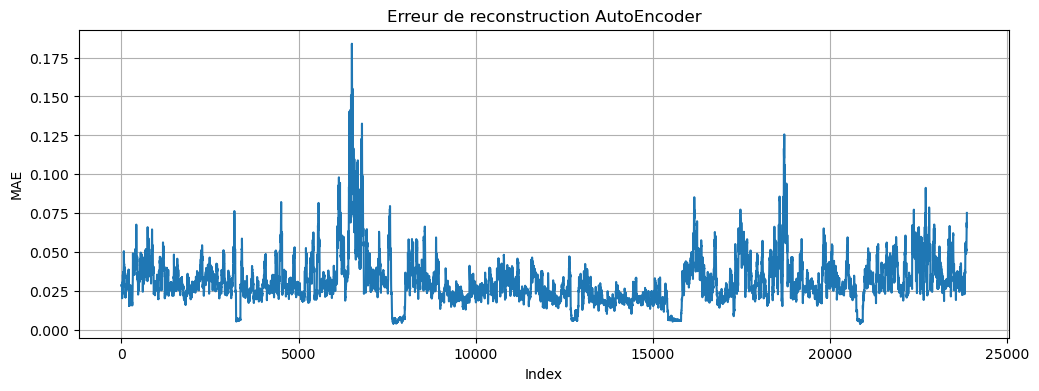

In [8]:
ae = load_model("../models/autoencoder_model.h5")
pred_ae = ae.predict(X_seq)
recons_error = np.mean(np.abs(pred_ae - X_seq), axis=(1, 2))

plt.figure(figsize=(12, 4))
plt.plot(recons_error)
plt.title("Erreur de reconstruction AutoEncoder")
plt.xlabel("Index")
plt.ylabel("MAE")
plt.grid(True)
plt.show()
